In [40]:
'''
Unsupervised clustering on CRISM data 
created on 15/05/2023 by Beatrice Baschetti

'''

'\nUnsupervised clustering on CRISM data \ncreated on 15/05/2023 by Beatrice Baschetti\nlatest update: 29/06/2024\n\n#4/10/23: added save option for df and df_nonan\n#17/10/23: added new data, fix colours of rgb histo, added if statement to contrast stretching\n#30/10/23: added ratio with a featureless spectrum of choice and smoothing of the resulted ratio\n#29/06/23: removed UMAP part (analysis with UMAP moved to a separate file), added scatter matrix visualization, rearranged and modified text/comments\n'

# Introduction

In this notebook two different <span style="color: orange;">unsupervised clustering</span> techniques available in the sci-kit learn library (https://scikit-learn.org/stable/) are applied to <span style="color: orange;">CRISM MTRDR I/F data</span> in the NIR range (1-2.6 microns). 

The featured algorithms are: 
1) K-means;
2) Gaussian mixture models.

Clustering is carried out on the I/F cube after a series of pre-processing steps and dimensionality reduction. Dimensionality of the data is here reduced through Principal Component Analysis (PCA). 

After clustering, it is possible to extract and plot the median spectra of the clusters. The spectra can be extracted either directly from the I/F cube or from a *ratioed* version of the same cube. A ratioed data cube is a cube where all the spectra are ratioed to a featureless spectrum (or the mean/median of several featureless spectra) within the same scene. The ratioed cube can be obtained by using the following script: https://github.com/beatricebs/crism-python-data-analysis/blob/main/CRISM_ratioed_cube_MTRDR.ipynb 

This tool was developed with the support of Dr. Mario D'Amore (DLR-Berlin).

# Import

In [1]:
#-----------python libraries-----------

#numpy
import numpy as np

#pandas
import pandas as pd

#plotting
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib inline
#colorcet -> https://colorcet.holoviz.org/user_guide/Categorical.html
import colorcet as cc

#open envi image
from spectral import open_image

#image stretching
from skimage import exposure

#clustering
from sklearn import decomposition
from sklearn import preprocessing
from sklearn import cluster
from sklearn import mixture

#computing time
import time

#folder/file management
import os

#-----------external custom functions-----------

from find_nearest import find_nearest #to find nearest value in a numpy array 


# Open image

In [2]:
#path
#path_if = 'data/FRT0000BEF5_07_IF165J_MTR3/frt0000bef5_07_if165j_mtr3.hdr' #put here the path of your data
path_if = 'data/FRT00009B5A_07_IF165J_MTR3/frt00009b5a_07_if165j_mtr3.hdr' #put here the path of your data

#opening I/F file
img = open_image(path_if)
wavelength = np.array(img.metadata['wavelength']).astype(float)

#if data is in micron you should convert to nm, uncomment this line if this is your case
#wavelength = wavelength*1000.

#getting the filename from path
filename = os.path.splitext(os.path.basename(path_if))[0]

#converting img to simple array and putting no-values to NaN
nan_img = np.copy(img[:,:,:])
nan_img[nan_img>10]=np.nan

# Cube visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


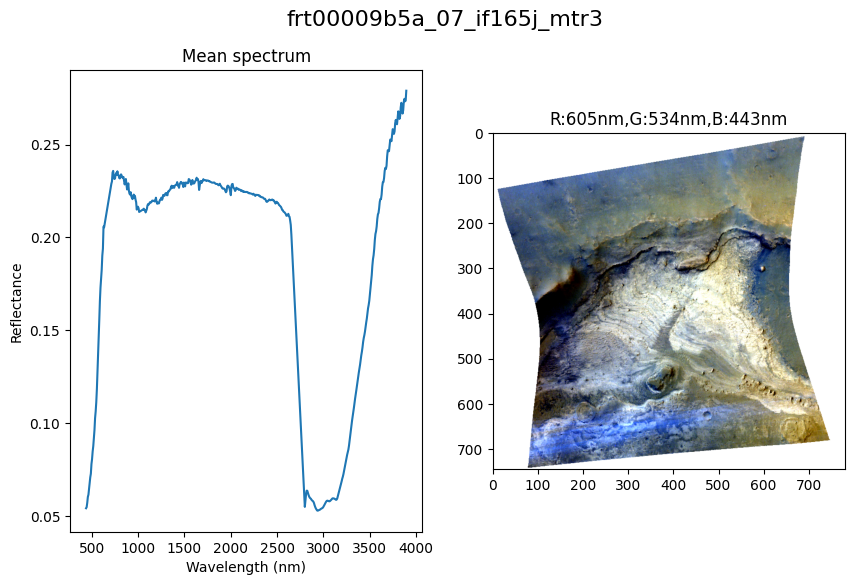

In [4]:
#computing mean spectrum
mean_spec = np.nanmean(nan_img.reshape(-1,nan_img.shape[-1]), axis = 0)

#RGB true color image
wav_channels = [26,15,1] #600nm,530nm,440nm
wav_channels_text = ','.join([f'{c}:{w:.0f}nm' for c,w in zip(['R','G','B'],wavelength[wav_channels])]) #channels text for plot
#slicing to get RGB
RGB = img[:,:,wav_channels]

#contrast stretching: 
for ind, ch in enumerate (RGB.T):
    #masking no-data values
    ch_mask = ch != 65535. 
    #2nd and 98th percentile ignoring no-data values (if present)
    p2, p98 = np.nanpercentile(ch[ch_mask], (2, 98)) 
    RGB[:,:,ind] = exposure.rescale_intensity(ch, in_range=(p2, p98)).T

#-----------plots-----------
fig, axs = plt.subplots(ncols=2,figsize=[10,6])
fig.suptitle(filename, fontsize = 16)

#mean spectrum (mean over the whole scene) plot
axs[0].plot(wavelength, mean_spec)
#title, labels...
axs[0].set_title('Mean spectrum')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Reflectance')

#image plot
axs[1].set_title(wav_channels_text)
axs[1].imshow(RGB)

plt.show()

#uncomment to save the image
#plt.savefig('crism_scene_'+filename,dpi=300)

# Preprocessing

There is a certain number of pre-processing steps to do before applying any clustering algorithm.

1) No-data/invalid values are removed (any value in the reflectance cube which is greater than 1)
2) Wavelength range is restricted between 1 and 2.6 microns. 
3) Data is filtered for artefacts: a) 1.645-1.704 (filter boundary artefact); b) 1.948-2.060 (CO2 artefact)

In [5]:
#create a pandas dataframe
df = pd.DataFrame(img[:,:,:].reshape(-1,img.shape[-1]),
            columns=wavelength/1000.
            )
print("-> df shape (initial data shape): %s" % str(df.shape))
df[df > 1] = np.nan #no-data/invalid values are put as NaNs


#->remove no-data values and resize the data to a smaller wavelength range
start_wav, stop_wav = 1.0, 2.6 #wavelengths between 1.0 and 2.6 microns
start_wav_ind, stop_wav_ind = find_nearest(start_wav,df.columns),find_nearest(stop_wav,df.columns) #get indexes
df_nonan = df.dropna(axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind] #drop NaN values and restrict wav. range
print("\nno-data values removed")
print("data is restricted between {}-{} um".format(start_wav, stop_wav))


#->remove ranges with artefacts
#----1.7 filter artefact:---- 
wv1_min_index = 169
wv1_max_index = 178
start_1 = wavelength[wv1_min_index]*0.001
stop_1 = wavelength[wv1_max_index]*0.001
#----CO2 artefact----
wv2_min_index = 215
wv2_max_index = 232
start_2 = wavelength[wv2_min_index]*0.001
stop_2 = wavelength[wv2_max_index]*0.001

print('filter artefact: {:.3f}-{:.3f} um;\nCO2 artefact: {:.3f}-{:.3f} um\n'.format(start_1, 
                                                                                    stop_1, 
                                                                                    start_2, 
                                                                                    stop_2))
df_nonan.loc[:,start_1:stop_1] = np.nan #1.7 filter artefact
df_nonan.loc[:,start_2:stop_2] = np.nan #CO2 artefact
#dropping NaN values on the columns (artefact gaps)
df_nonan = df_nonan.dropna(axis=1, how='all')
#-----------------------------------

#check shape
print("-> df_nonan shape (final data shape): %s" % str(df_nonan.shape))

-> df shape (initial data shape): (581064, 489)

no-data values removed
data is restricted between 1.0-2.6 um
filter artefact: 1.645-1.704 um;
CO2 artefact: 1.948-2.060 um

-> df_nonan shape (final data shape): (394890, 211)


<Axes: title={'center': 'Sample spectra from df_nonan'}>

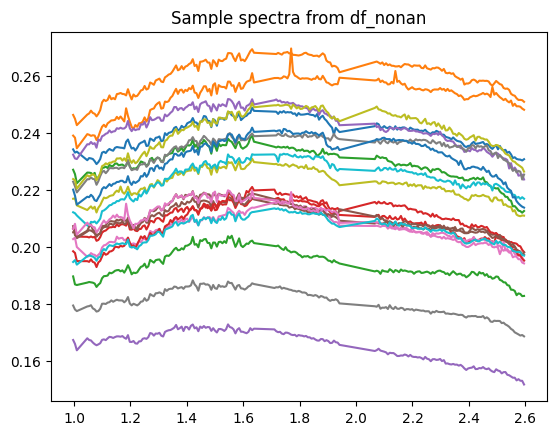

In [6]:
#This plot visualizes random spectra from the data (gaps are connected by a straight line)
df_nonan.sample(20).T.plot(title = 'Sample spectra from df_nonan', legend=None)

## Save df and df_nonan

In [29]:
#save df and df_nonan

#---> this data is to be used in the silhouette script, save this only once,
#df and df_nonan will be the same for every clustering algorithm

#df.to_pickle("output/out_9b5a/df_"+filename+".pkl")
#df_nonan.to_pickle("output/out_9b5a/df_nonan_"+filename+".pkl")

# Principal Component Analysis (PCA)

The large number of bands in hyperspectral cubes make it a very high-dimensional dataset, impacting the performance of the clustering algorithms. Principal component analysis (PCA) is a simple solution to reduce the dimensionality of the data, improving the quality of clustering. 

In [12]:
X = df_nonan.values #data array

n_components = 6 #number of pca components
pca = decomposition.PCA(n_components=n_components)
pca.fit(X)
n_components = pca.n_components_
X_pca = pca.transform(X)


print('X.shape               : {}\n'
      'X_pca.shape           : {}\n'
      'pca.components_.shape : {}'.format(X.shape, X_pca.shape, pca.components_.shape))

print("              variance       var_ratio      cum_var_ratio")
for i in range(n_components):
    print("Component %2s: %12.10f   %12.10f   %12.10f" % (i, pca.explained_variance_[i], 
                                                          pca.explained_variance_ratio_[i], 
                                                          np.cumsum(pca.explained_variance_ratio_)[i]))


X.shape               : (394890, 211)
X_pca.shape           : (394890, 6)
pca.components_.shape : (6, 211)
              variance       var_ratio      cum_var_ratio
Component  0: 0.1466776282   0.9925562739   0.9925562739
Component  1: 0.0006721542   0.0045484160   0.9971047044
Component  2: 0.0002019716   0.0013667266   0.9984714389
Component  3: 0.0000496251   0.0003358095   0.9988072515
Component  4: 0.0000416639   0.0002819366   0.9990891814
Component  5: 0.0000334594   0.0002264172   0.9993156195


initial data size:(581064, 489)
filtered data size:(394890, 211)
data size after PCA:(394890, 6)



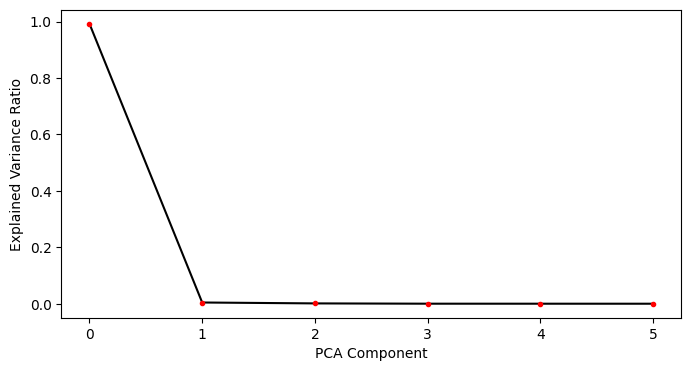

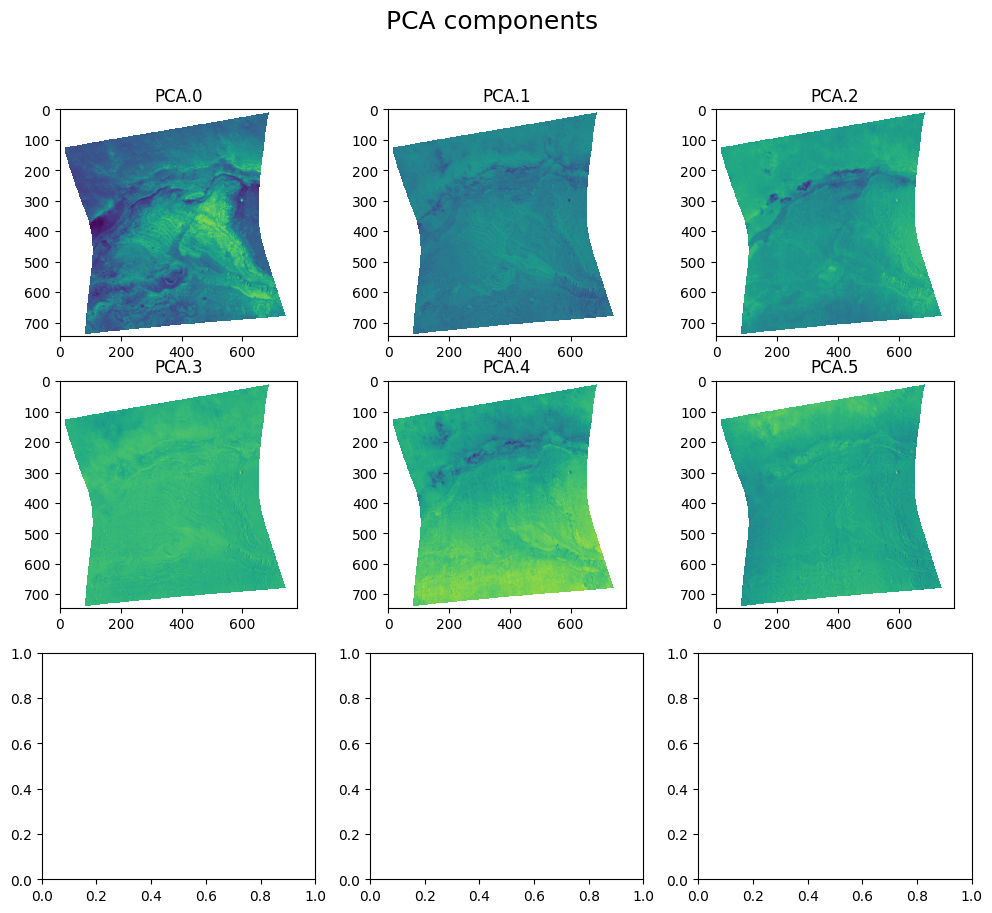

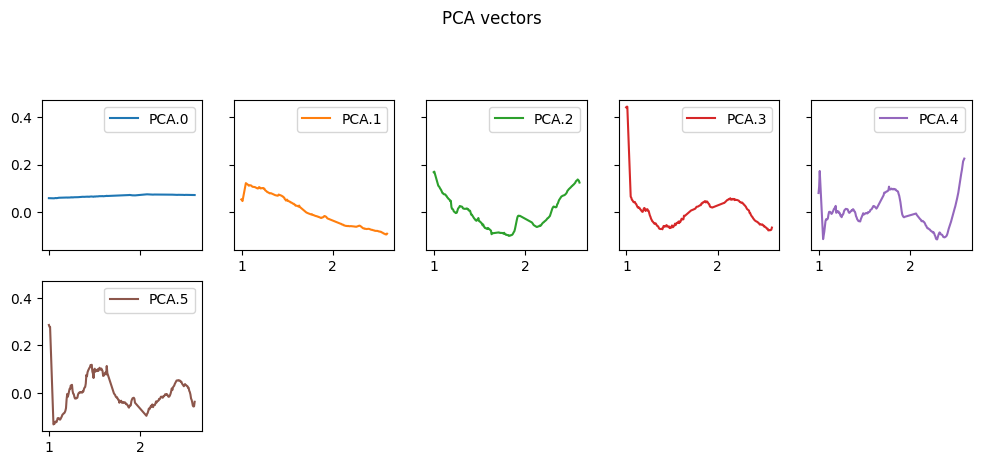

In [13]:
#visualize pca components

print("initial data size:{}\nfiltered data size:{}\ndata size after PCA:{}\n".format(df.shape,df_nonan.shape,X_pca.shape)) #some info on data shape
    
#---------plot of explained variance---------
components_shift = 0 #if components_shift=1 first pca component is not shown in the figure.
fig = plt.figure(figsize=(8,4))
ax = plt.subplot()
ax.plot(np.arange(pca.n_components-components_shift)+components_shift, pca.explained_variance_ratio_[components_shift:], c="black")
ax.plot(np.arange(pca.n_components-components_shift)+components_shift, pca.explained_variance_ratio_[components_shift:], "r.")

ax.set_xlabel("PCA Component")  
ax.set_ylabel("Explained Variance Ratio") 
#ax.set_yscale('log') #uncomment to set logarithmic scale on y axis

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) #ensure axis only shows integers



#---------plot pca components---------
plot_df = pd.DataFrame(index=df.index) #create a plot dataframe

for cmp in range(pca.n_components): #set column names
    plot_df[f'PCA.{cmp}'] = np.nan 
    
plot_df.loc[df_nonan.index] = X_pca #fill columns

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=[12,10]) #rows and columns can be manually adjusted based on n_components
fig.suptitle("PCA components", size = 18)
axs = axs.flatten()
    
for ind, ax in enumerate(axs):
    if ind < n_components:
        ax.imshow(plot_df.iloc[:,ind].values.reshape(img.shape[:-1]))
        ax.set_title(plot_df.columns[ind])
        


#---------plot pca vectors--------- 
pca_vectors = pd.DataFrame(columns=df_nonan.columns,
                        index=[ f'PCA.{cmp}' for cmp in range(pca.n_components)],
                        data=pca.components_)

pca_vectors.T.plot(subplots=True,figsize=[12,9], layout = (4,5), sharey = True, title = 'PCA vectors')

plt.show()  


### Remove first component of PCA (suggested)
Removing the first component of the PCA from the data will remove the dependency on reflectance of the clustering algorithms. This will help the algorithms to focus more on bands and slope differences rather than the differences in reflectance levels

In [14]:
#first component of X_pca is removed (run this cell only once!)
X_pca = X_pca[:,1:]
print('First component of PCA removed! X_pca.shape =', X_pca.shape)

First component of PCA removed! X_pca.shape = (394890, 5)


# Clustering
There are several kinds of estimators https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html 

For CRISM hyperspectral data k-means and gaussian mixture work fine, and they are fast.

## Scaler
Data needs to be scaled before passing them to the clustering algorithm -> https://scikit-learn.org/stable/modules/preprocessing.html

Here the "standard scaler" is used -> https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py


In [16]:

scaler = preprocessing.StandardScaler().fit(X_pca)
X_scaled = scaler.transform(X_pca)

#scaled data has zero mean and unit variance
print('Scaled data info:\n')
print('Mean:',X_scaled.mean(axis=0))
print('Std:',X_scaled.std(axis=0))

Scaled data info:

Mean: [-1.6651095e-06 -1.1855797e-06 -1.4750282e-07  3.3693734e-06
  4.5621118e-06]
Std: [0.9999433  0.99991983 0.9999231  0.9999569  0.9999103 ]


In [34]:
#here you can save the scaled data, uncomment the line below
#np.save('output/X_scaled_PCA_' + str(n_components) + '-1_UMAP_' + filename + '.npy', X_scaled) #PCA - 1st component

## Scatter matrix

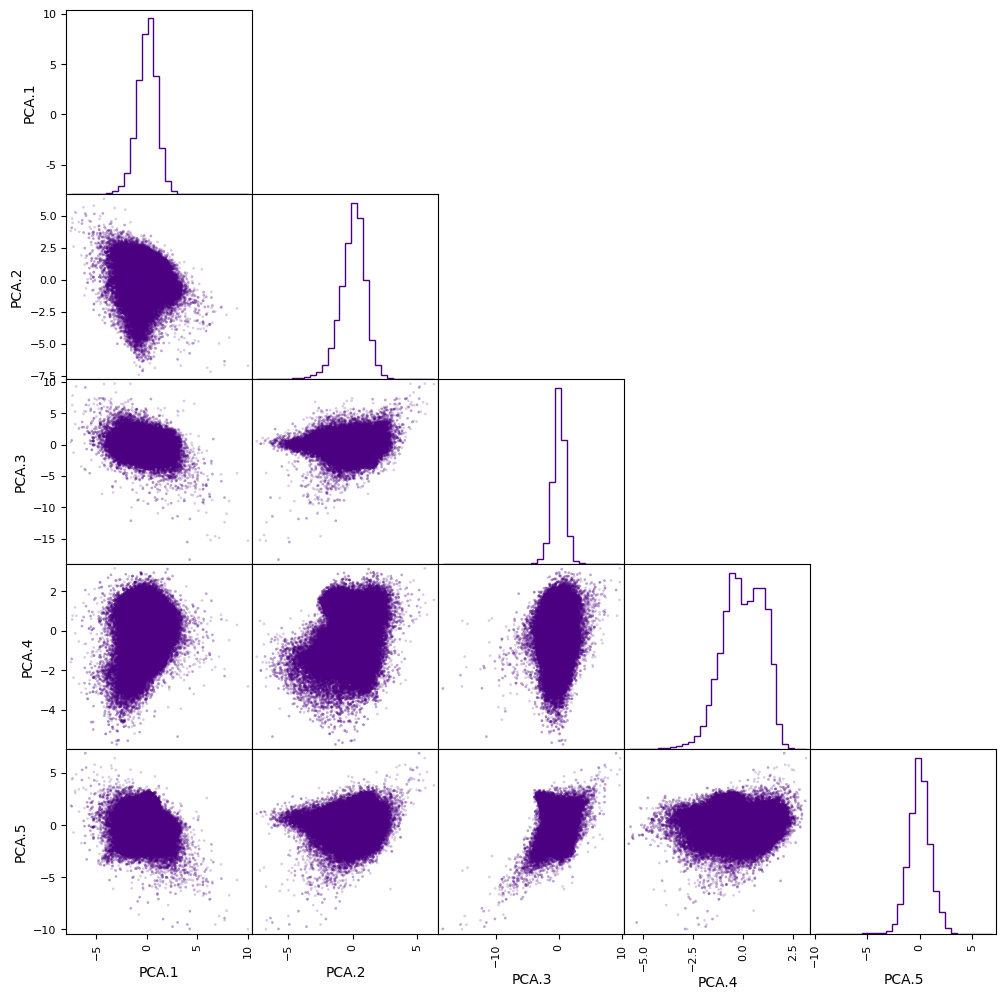

In [17]:
#it can be useful to visualize the scatter matrix of the data to get an idea of its shape

df_scaled = pd.DataFrame(X_scaled, columns = [f'PCA.{c}' for c in range(1,n_components)]) #1 -> PCA - 1st component; 0-> All PCA components
axes = pd.plotting.scatter_matrix(df_scaled, figsize=[12,12], color='indigo', alpha=0.2, hist_kwds={'bins':30, 'histtype':'step', 'color':'indigo'}, s=15)

#visualizing only half of the matrix
for i in range(np.shape(axes)[0]):
    for j in range(np.shape(axes)[1]):
        if i<j:
            axes[i,j].set_visible(False)
plt.show()

## Clustering 
You can choose between k-means algorithm (https://scikit-learn.org/stable/modules/clustering.html#k-means) and gaussian mixture models (https://scikit-learn.org/stable/modules/mixture.html#mixture)

Uncomment the relevant part

In [16]:
#Here you can load the scaled data you saved before. 
#This is useful in case you don't want to go through all the preprocessing and dimensionality reduction multiple times between different runs.

#X_scaled = np.load('output/X_scaled_PCA_' + str(n_components) + '-1_' + filename + '.npy') #put your chosen path here

In [18]:
#----------- K-means -----------------

from sklearn import cluster

classifier = 'K-Means'
n_clusters = 11

#computation time start
start_time = time.time()

#K-means estimator instance + classify scaled data
k_means = cluster.KMeans(n_clusters=n_clusters, init = 'k-means++', n_init=1, random_state=1111).fit(X_scaled)
labels = k_means.labels_
print('k_means.inertia_ : ',k_means.inertia_)

#computation time end
end_time = time.time()
computation_time = end_time - start_time
#print computation time
print("Computation time:", computation_time, "seconds")




#------------ Gaussian Mixture -------------

'''

from sklearn import mixture

classifier = 'Gaussian Mixture'
n_clusters = 7

#computation time start
start_time = time.time()

#choose from: full, tied, diag, spherical 
covariance_type = 'full'
#choose from: kmeans, k-means++, random, random_from_data
init_params = 'kmeans'
g_mixture = mixture.GaussianMixture(n_components=n_clusters, random_state=1111, covariance_type = covariance_type, init_params = init_params)
labels = g_mixture.fit_predict(X_scaled) 

#computation time end
end_time = time.time()
computation_time = end_time - start_time
#print computation time
print("Computation time:", computation_time, "seconds")

'''


k_means.inertia_ :  772096.0
Computation time: 0.2794780731201172 seconds


'\n\nfrom sklearn import mixture\n\nclassifier = \'Gaussian Mixture\'\nn_clusters = 7\n\n#computation time start\nstart_time = time.time()\n\n#choose from: full, tied, diag, spherical \ncovariance_type = \'full\'\n#choose from: kmeans, k-means++, random, random_from_data\ninit_params = \'kmeans\'\ng_mixture = mixture.GaussianMixture(n_components=n_clusters, random_state=1111, covariance_type = covariance_type, init_params = init_params)\nlabels = g_mixture.fit_predict(X_scaled) \n\n#computation time end\nend_time = time.time()\ncomputation_time = end_time - start_time\n#print computation time\nprint("Computation time:", computation_time, "seconds")\n\n'

## Visualize clusters

### Relabelling of features with centroids (optional)
Normally, the k-means algorithm assigns labels to clusters randomly.
In this part of the code you can change how the labels are assigned to the clusters as originally implemented here https://gist.github.com/kidpixo/6ec6c6c575e19b09da3d2207efa38b24

Labels are assigned based on the reflectance value at a chosen wavelength of each class' mean spectrum. If the generated classes are similar between k-means algorithm and GMMs, colors should stay the same allowing the user to easily compare the different methods.

In [19]:
y = df_nonan.groupby(labels).mean().values #get mean spectrum of each cluster

feature_index = find_nearest(2.5, df_nonan.columns.values) #choose the wavelength and get the corresponding index
centroids_sorting_index = np.argsort(y[:, feature_index]) #get index that sorts y at the chosen feature 
centroids_sorted_labels = np.argsort(centroids_sorting_index) #this operation produces an array with the sorted labels 

# change the classes with the new integers 
labels = pd.Series(labels).map(dict(zip(np.arange(n_clusters), centroids_sorted_labels))).values.squeeze()

#visualize old and new indexes
print(f'index for label sort: index : {feature_index} - wav : {df_nonan.columns[feature_index]:1.3f} um')
print(f'ind : y_feat > new_index')
for i, yf, ni in zip(range(len(y[:, feature_index])),y[:,feature_index], centroids_sorted_labels):
    print(f'{i:3} : {yf:2.3f} > {ni:>4}')

index for label sort: index : 196 - wav : 2.503 um
ind : y_feat > new_index
  0 : 0.210 >    2
  1 : 0.218 >    5
  2 : 0.201 >    0
  3 : 0.229 >    7
  4 : 0.235 >    9
  5 : 0.201 >    1
  6 : 0.212 >    3
  7 : 0.237 >   10
  8 : 0.217 >    4
  9 : 0.226 >    6
 10 : 0.231 >    8


### Assign labels

In [20]:
#going back to data cubes
class_plot_df = pd.DataFrame(index=df.index)

#assign labels
class_plot_df['labels'] = np.nan
labels = labels.reshape(-1,1)
class_plot_df.loc[df_nonan.index] = labels

### Plot

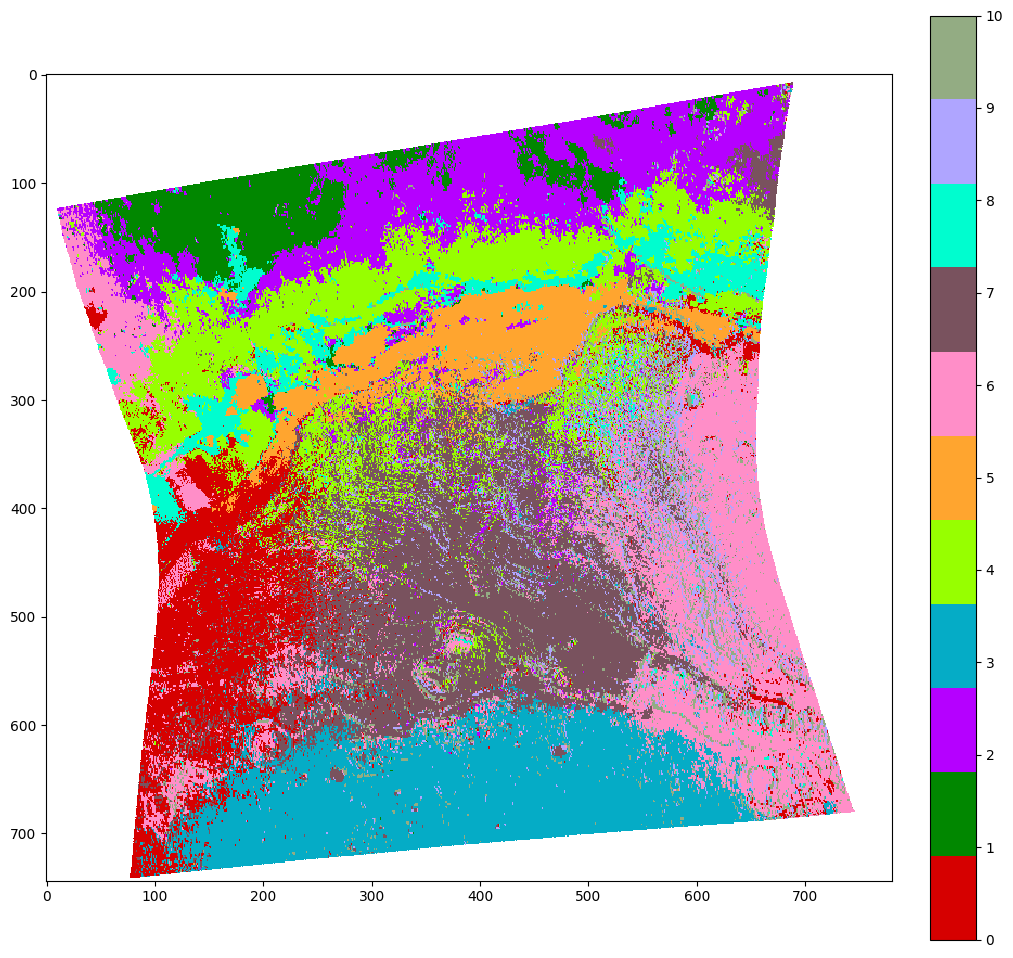

In [21]:
#plotting the clusters----------

fig = plt.subplots(figsize=(12,12))

#colors
color_list = cc.glasbey_light[:n_clusters]
cmap = ListedColormap(color_list)

#since the new clusters labels are based on reflectance values of a certain feature
#with a continuous color map you can shown how these values change with the class
#in that case you can uncomment the line below
#cmap = plt.cm.Spectral_r 
 
im = plt.imshow(class_plot_df['labels'].values.reshape(img.shape[:-1]),interpolation='None',cmap=cmap) 

#color bar
cbar = plt.colorbar(im, fraction = 0.05, pad = 0.04)

# Set the number of ticks on the color bar
num_ticks = n_clusters
cbar.locator = plt.MaxNLocator(num_ticks)
# Update the color bar
cbar.update_ticks()

#save img (make sure to save at a high-res!)
#plt.savefig('output/figures/'+filename+'_pca'+classifier+'.png', dpi= 300)

plt.show()


C:\Users\francesc0\AppData\Local\Temp\ipykernel_19480\2560917335.py:19: FutureWarning: The provided callable <function median at 0x0000023F551559E0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  spectra = df_nonan.groupby(labels.squeeze()).agg(np.median).T


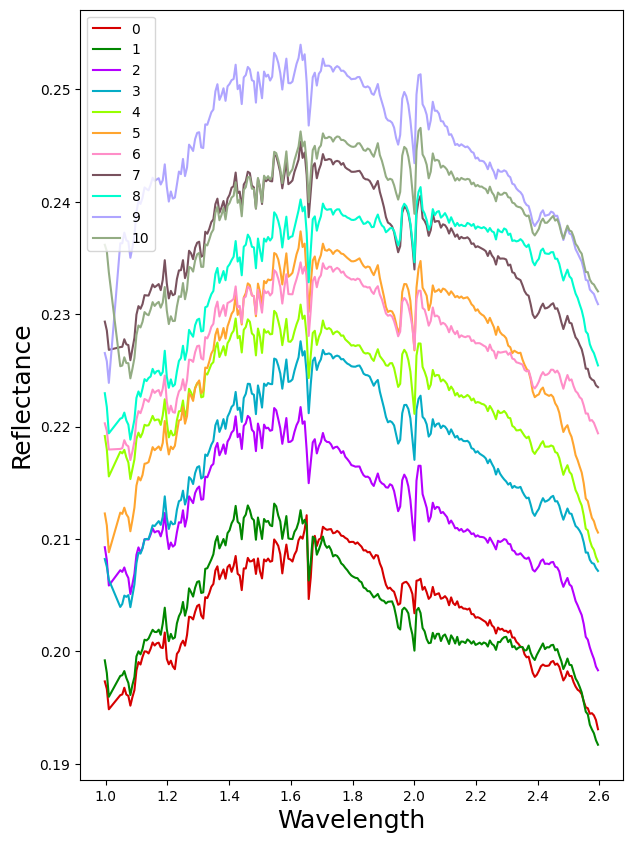

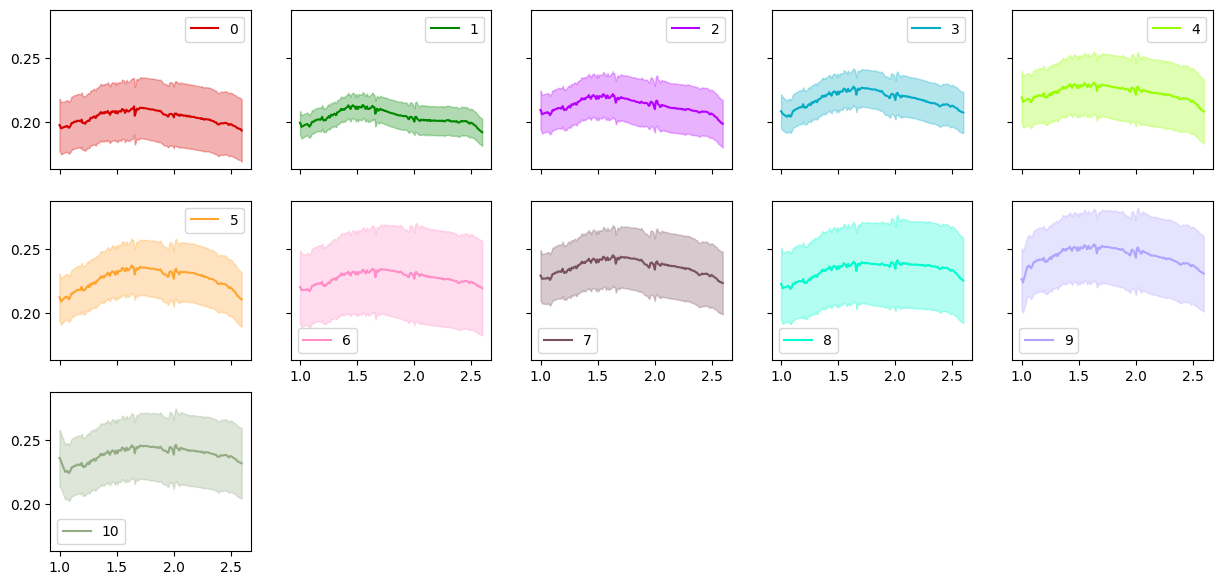

In [23]:
#plotting the median spectra of the clusters identified by the algorithm

start_wav, stop_wav = 1.0, 2.6 #reduce data to wavelengths between 1.0 and 2.6 microns
start_wav_ind , stop_wav_ind = find_nearest(start_wav,df.columns),find_nearest(stop_wav,df.columns)
#-------------- read df again
#using pandas dataframes
df = pd.DataFrame(img[:,:,:].reshape(-1,img.shape[-1]),
            columns=wavelength/1000.
            )
#putting rows and columns with no-data values to NaN
df[df > 1] = np.nan #no data values
#--------------
#drop nans
df_nonan = df.dropna(
    axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind]


# Plot median values all in one figure--------------
spectra = df_nonan.groupby(labels.squeeze()).agg(np.median).T
ax = spectra.plot(figsize=[7,10], cmap = cmap)
#labels
ax.set_xlabel('Wavelength', fontsize=18)
ax.set_ylabel('Reflectance', fontsize = 18)


#plot each spectrum separately--------------
# Calculate median and standard deviation for each cluster
grouped_data = df_nonan.groupby(labels.squeeze())
median_values = grouped_data.median()
std_values = grouped_data.std()
#plot
axs = median_values.T.plot(subplots=True, figsize=[15,12], layout = (5,5), sharey = True, cmap = cmap)
axs = axs.flatten()
for i, row in enumerate(median_values.index):
    axs[i].fill_between(median_values.columns, 
                        median_values.iloc[i,:]-std_values.iloc[i,:], 
                        median_values.iloc[i,:]+std_values.iloc[i,:], 
                        alpha=0.3, 
                        color = cmap(i))

#save data as a dataframe to plot later...and avoid overwrite! (uncomment to use)
'''
path_ = 'output/out_9b5a/spectra_df_'+filename+'_'+classifier+'_pca.pkl' #uncomment to save!


if not os.path.exists(path_): 
    
    spectra.to_pickle(path_)
    print('File saved!')

else: print('File already exists!')

'''

# Load ratioed cube
If you have a ratioed cube at your disposal, you can see how the ratioed spectra look like for each cluster. To get a ratioed version of MTRDR cubes see https://github.com/beatricebs/crism-python-data-analysis/blob/main/CRISM_ratioed_cube_MTRDR.ipynb

In [26]:
#path
path_if_ratioed = 'data/FRT00009B5A_07_IF165J_MTR3/frt00009b5a_07_if165j_mtr3_RATIOED1.hdr' #put here the path to your ratioed cube

#opening file
img_ratioed = open_image(path_if_ratioed)
#dataframe
df_ratioed = pd.DataFrame(img_ratioed[:,:,:].reshape(-1,img_ratioed.shape[-1]),
            columns=wavelength/1000.
            )
#drop nans
df_ratioed = df_ratioed.dropna(axis=0,how='all').iloc[:,start_wav_ind:stop_wav_ind]

### Plot

C:\Users\francesc0\AppData\Local\Temp\ipykernel_19480\1546463347.py:10: FutureWarning: The provided callable <function nanmedian at 0x0000023F55161260> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  spectra_ratioed = df_ratioed.groupby(labels.squeeze()).agg(np.nanmedian).T


"\npath_ = 'output/out_9b5a/spectra_ratioed_'+filename+'_'+classifier+'_pca.pkl' #uncomment to save!\n\n\nif not os.path.exists(path_): \n    \n    spectra.to_pickle(path_)\n    print('File saved!')\n\nelse: print('File already exists!')\n"

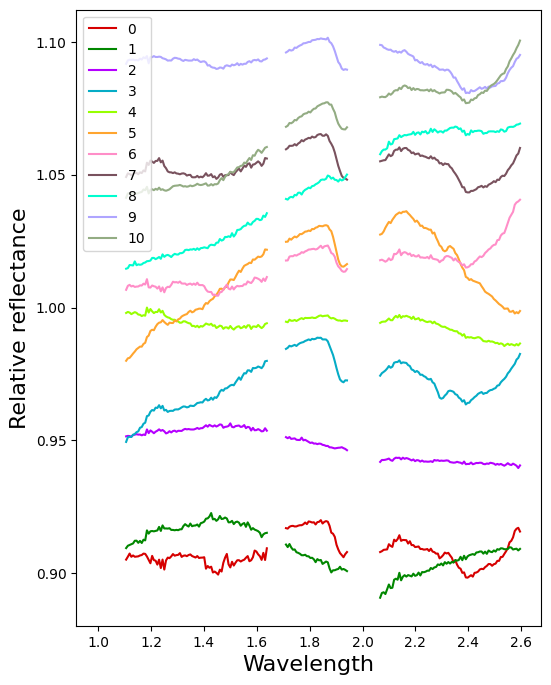

In [28]:
#plot

#mask artefacts
df_ratioed.loc[:,start_1:stop_1] = np.nan #1.7 filter artefact
df_ratioed.loc[:,start_2:stop_2] = np.nan #CO2 artefact

#mask first part of spectrum
df_ratioed.loc[:,1:1.1] = np.nan

spectra_ratioed = df_ratioed.groupby(labels.squeeze()).agg(np.nanmedian).T
ax = spectra_ratioed.plot(figsize=[6,8], cmap = cmap)

#uncomment for smoothing
'''
from scipy.signal import savgol_filter
#smoothed_spectra = savgol_filter(spectra_ratioed, 5, 2, axis = 0)
#smoothed_spectra_df = pd.DataFrame(smoothed_spectra, index = spectra_ratioed.index, columns = spectra_ratioed.columns)

#ax = smoothed_spectra_df.plot(figsize=[7,10], cmap = cmap)
'''

ax.set_xlabel('Wavelength', fontsize=16)
ax.set_ylabel('Relative reflectance', fontsize = 16)


#save data as a dataframe to plot later...and avoid overwrite! (uncomment to use)
'''
path_ = 'output/out_9b5a/spectra_ratioed_'+filename+'_'+classifier+'_pca.pkl' #uncomment to save!


if not os.path.exists(path_): 
    
    spectra.to_pickle(path_)
    print('File saved!')

else: print('File already exists!')
'''

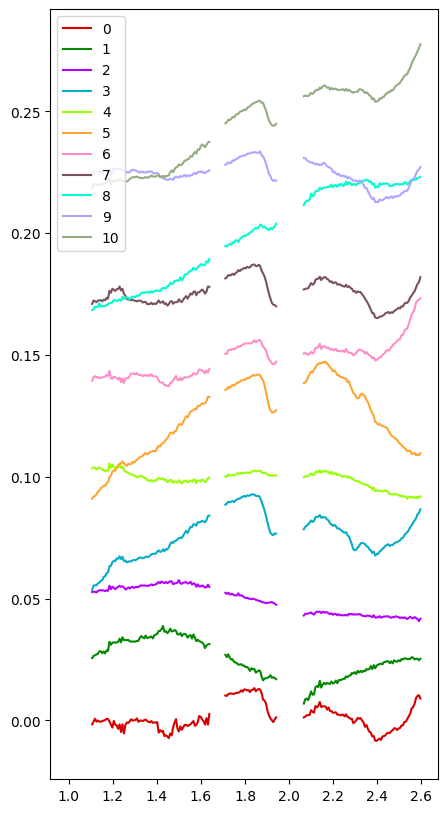

In [29]:
#plot with a sistematic shift

r = [r/40.0 for r in range(0,len(spectra_ratioed.columns))] #shift
ratioed_spectra_shift_df = spectra_ratioed-spectra_ratioed.median()+r
ax = ratioed_spectra_shift_df.plot(figsize=[5,10], cmap = cmap)
